In [1]:
from langgraph.graph import MessagesState
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
from langchain_core.messages import HumanMessage, RemoveMessage
from langgraph.graph import StateGraph, START
from langgraph.checkpoint.memory import InMemorySaver
import os

In [2]:
load_dotenv()



api_key = os.getenv("GROQ_API_KEY")

model = ChatOpenAI(
    model="openai/gpt-oss-120b",
    base_url="https://api.groq.com/openai/v1",
    api_key=api_key
)

In [3]:
class ChatState(MessagesState):
    summary: str

In [4]:
def chat_node(state: ChatState):
    messages = []

    if state["summary"]:
        messages.append({
            "role": "system",
            "content": f"Conversation summary:\n{state['summary']}"
        })

    messages.extend(state["messages"])

    print(messages)

    response = model.invoke(messages)
    return {"messages": [response]}

In [5]:
def summarize_conversation(state: ChatState):

    existing_summary = state["summary"]

    # Build summarization prompt
    if existing_summary:
        prompt = (
            f"Existing summary:\n{existing_summary}\n\n"
            "Extend the summary using the new conversation above."
        )
    else:
        prompt = "Summarize the conversation above."

    messages_for_summary = state["messages"] + [
        HumanMessage(content=prompt)
    ]

    response = model.invoke(messages_for_summary)

    # Keep only last 2 messages verbatim
    messages_to_delete = state["messages"][:-2]

    return {
        "summary": response.content,
        "messages": [RemoveMessage(id=m.id) for m in messages_to_delete],
    }

In [6]:
def should_summarize(state: ChatState):
    return len(state["messages"]) > 6

In [7]:
builder = StateGraph(ChatState)

builder.add_node("chat", chat_node)
builder.add_node("summarize", summarize_conversation)

builder.add_edge(START, "chat")

builder.add_conditional_edges(
    "chat",
    should_summarize,
    {
        True: "summarize",
        False: "__end__",
    }
)

builder.add_edge("summarize", "__end__")

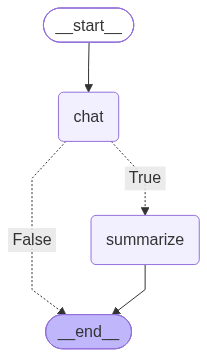

In [8]:
checkpointer = InMemorySaver()
graph = builder.compile(checkpointer=checkpointer)
graph

In [9]:
config = {"configurable": {"thread_id": "t1"}}

In [10]:

# gives the current version of the state
def show_state():
    snap = graph.get_state(config)
    vals = snap.values
    print("\n--- STATE ---")
    print("summary:", vals.get("summary", ""))
    print("num_messages:", len(vals.get("messages", [])))
    print("messages:")
    for m in vals.get("messages", []):
        print("-", type(m).__name__, ":", m.content[:80])

In [11]:
# First invocation
out = graph.invoke({"messages": [HumanMessage(content='Quantum Physics on 200 words')], 'summary': ''}, config=config)
print(out)
show_state()

[HumanMessage(content='Quantum Physics on 200 words', additional_kwargs={}, response_metadata={}, id='4f3f5844-25de-4fb9-87e9-cc81a454f261')]
{'messages': [HumanMessage(content='Quantum Physics on 200 words', additional_kwargs={}, response_metadata={}, id='4f3f5844-25de-4fb9-87e9-cc81a454f261'), AIMessage(content='Quantum physics is the branch of science that describes the behavior of matter and energy at the smallest scales—atoms, electrons, photons, and other subatomic particles. Unlike classical physics, it embraces principles that appear counterintuitive: particles exist in superpositions, simultaneously occupying multiple states until measured, and they become entangled, sharing instantaneous correlations regardless of distance. The wave‑particle duality reveals that entities such as light and electrons display both wave‑like interference patterns and particle‑like impacts, a duality formalized by the Schrödinger equation and Heisenberg’s uncertainty principle, which limits the pr

In [12]:
# Second invocation
out = graph.invoke({"messages": [HumanMessage(content='How is Albert Einstien related in 200 words?')], }, config=config)
print(out)
show_state()

[HumanMessage(content='Quantum Physics on 200 words', additional_kwargs={}, response_metadata={}, id='4f3f5844-25de-4fb9-87e9-cc81a454f261'), AIMessage(content='Quantum physics is the branch of science that describes the behavior of matter and energy at the smallest scales—atoms, electrons, photons, and other subatomic particles. Unlike classical physics, it embraces principles that appear counterintuitive: particles exist in superpositions, simultaneously occupying multiple states until measured, and they become entangled, sharing instantaneous correlations regardless of distance. The wave‑particle duality reveals that entities such as light and electrons display both wave‑like interference patterns and particle‑like impacts, a duality formalized by the Schrödinger equation and Heisenberg’s uncertainty principle, which limits the precision with which complementary properties (position and momentum) can be known. Quantum mechanics also introduces quantization, the idea that energy, ang

In [13]:
# Second invocation
out = graph.invoke({"messages": [HumanMessage(content='How is newton related in 200 words?')], }, config=config)
print(out)
show_state()

[HumanMessage(content='Quantum Physics on 200 words', additional_kwargs={}, response_metadata={}, id='4f3f5844-25de-4fb9-87e9-cc81a454f261'), AIMessage(content='Quantum physics is the branch of science that describes the behavior of matter and energy at the smallest scales—atoms, electrons, photons, and other subatomic particles. Unlike classical physics, it embraces principles that appear counterintuitive: particles exist in superpositions, simultaneously occupying multiple states until measured, and they become entangled, sharing instantaneous correlations regardless of distance. The wave‑particle duality reveals that entities such as light and electrons display both wave‑like interference patterns and particle‑like impacts, a duality formalized by the Schrödinger equation and Heisenberg’s uncertainty principle, which limits the precision with which complementary properties (position and momentum) can be known. Quantum mechanics also introduces quantization, the idea that energy, ang

{'messages': [HumanMessage(content='Quantum Physics on 200 words', additional_kwargs={}, response_metadata={}, id='4f3f5844-25de-4fb9-87e9-cc81a454f261'), AIMessage(content='Quantum physics is the branch of science that describes the behavior of matter and energy at the smallest scales—atoms, electrons, photons, and other subatomic particles. Unlike classical physics, it embraces principles that appear counterintuitive: particles exist in superpositions, simultaneously occupying multiple states until measured, and they become entangled, sharing instantaneous correlations regardless of distance. The wave‑particle duality reveals that entities such as light and electrons display both wave‑like interference patterns and particle‑like impacts, a duality formalized by the Schrödinger equation and Heisenberg’s uncertainty principle, which limits the precision with which complementary properties (position and momentum) can be known. Quantum mechanics also introduces quantization, the idea tha

In [14]:
# Second invocation
out = graph.invoke({"messages": [HumanMessage(content='How is Albert Einstien famous work 200 words?')],}, config=config)
print(out)
show_state()

[HumanMessage(content='Quantum Physics on 200 words', additional_kwargs={}, response_metadata={}, id='4f3f5844-25de-4fb9-87e9-cc81a454f261'), AIMessage(content='Quantum physics is the branch of science that describes the behavior of matter and energy at the smallest scales—atoms, electrons, photons, and other subatomic particles. Unlike classical physics, it embraces principles that appear counterintuitive: particles exist in superpositions, simultaneously occupying multiple states until measured, and they become entangled, sharing instantaneous correlations regardless of distance. The wave‑particle duality reveals that entities such as light and electrons display both wave‑like interference patterns and particle‑like impacts, a duality formalized by the Schrödinger equation and Heisenberg’s uncertainty principle, which limits the precision with which complementary properties (position and momentum) can be known. Quantum mechanics also introduces quantization, the idea that energy, ang

In [15]:
# Second invocation
out = graph.invoke({"messages": [HumanMessage(content='How is Albert Einstien life in 200 words?')],}, config=config)
print(out)
show_state()

[{'role': 'system', 'content': 'Conversation summary:\n**Conversation Summary**\n\n1. **Quantum Physics (≈200\u202fwords)** – Explained that quantum physics governs matter and energy at atomic and sub‑atomic scales, highlighting superposition, entanglement, wave‑particle duality, the Schrödinger equation, Heisenberg’s uncertainty principle, quantization, and key applications such as lasers, semiconductors, MRI, and quantum computing.\n\n2. **Albert\u202fEinstein’s Connection to Quantum Physics (≈200\u202fwords)** – Described Einstein’s seminal contributions: the 1905 photo‑electric effect paper (introducing photons), the concept of stimulated emission, and his later philosophical challenge via the 1935 EPR paper, which questioned quantum completeness and spurred research into entanglement and Bell’s theorem. Emphasized his dual legacy as both a pioneer and a critical voice.\n\n3. **Isaac\u202fNewton’s Relation to Quantum Physics (≈200\u202fwords)** – Outlined Newton’s classical mechani